#**CREDIT RISK PREDICTION USING MACHINE LEARNING AND AI**
***Complete Implementation***


---



## **INSTALLATION OF REQUIRED PACKAGES FOR THE MODELS**

In [ ]:
# -------------------------------
# 1. INSTALL REQUIRED PACKAGES
# -------------------------------
!pip install xgboost shap imbalanced-learn pandas-profiling --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 110.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.0/103.0 kB 123.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 69.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 37.0 kB/s eta 0:00:00


## **IMPORT ALL REQUIRED LIBRARIES**

In [ ]:
# -------------------------------
# 2. IMPORT LIBRARIES
# -------------------------------

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline as make_imb_pipeline

# Interpretability
import shap

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## **MOUNT GOOGLE DRIVE**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **DOWNLOAD AND LOAD DATASET REQUIRED FOR THE MODELS**
Publicly available dataset is used for this project.

Dowloaded and available at:

https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset

Data also checked for the shape

In [ ]:
# -------------------------------
# 3. DOWNLOAD AND LOAD DATASET
# -------------------------------

from google.colab import files
import zipfile
import os

# Unzip the file
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Give-Me-Some-Credit-Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/credit_data')

# Load the data
train_data = pd.read_csv('/content/credit_data/cs-training.csv')
test_data = pd.read_csv('/content/credit_data/cs-test.csv')

# Check the data
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
print("\nTraining data columns:", train_data.columns.tolist())

Training data shape: (150000, 12)
Test data shape: (101503, 12)

Training data columns: ['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [ ]:
# Rename columns (remove 'Unnamed: 0' if present)
if 'Unnamed: 0' in train_data.columns:
    train_data = train_data.drop('Unnamed: 0', axis=1)
if 'Unnamed: 0' in test_data.columns:
    test_data = test_data.drop('Unnamed: 0', axis=1)
    test_data = test_data.drop('SeriousDlqin2yrs', axis=1)
    # Test data has target column but we'll use it for validation

In [ ]:
# Rename columns for easier handling
column_names = {
    'SeriousDlqin2yrs': 'target',
    'RevolvingUtilizationOfUnsecuredLines': 'revolving_util',
    'age': 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'delinq_30_59',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'num_open_credit',
    'NumberOfTimes90DaysLate': 'delinq_90',
    'NumberRealEstateLoansOrLines': 'num_real_estate',
    'NumberOfTime60-89DaysPastDueNotWorse': 'delinq_60_89',
    'NumberOfDependents': 'num_dependents'
}

# Rename columns if they exist
if train_data.columns[0] == 'Unnamed: 0':
    train_data = train_data.iloc[:, 1:]
if test_data.columns[0] == 'Unnamed: 0':
    test_data = test_data.iloc[:, 1:]

train_data.columns = list(column_names.values()) if len(train_data.columns) == len(column_names) else train_data.columns
test_data.columns = list(column_names.values())[1:] if len(test_data.columns) == len(column_names)-1 else test_data.columns

## **EXPLORATORY DATA ANALYSIS**

In [ ]:
# -------------------------------
# 4. EXPLORATORY DATA ANALYSIS
# -------------------------------

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Basic info
print("\n--- Dataset Info ---")
print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")


EXPLORATORY DATA ANALYSIS

--- Dataset Info ---
Training set size: 150000
Test set size: 101503


### **Target Distribution**

In [ ]:
# Target distribution
print("\n--- Target Distribution ---")
target_dist = train_data['target'].value_counts()
target_perc = train_data['target'].value_counts(normalize=True) * 100
target_df = pd.DataFrame({'Count': target_dist, 'Percentage': target_perc})
print(target_df)


--- Target Distribution ---
         Count  Percentage
target                    
0       139974      93.316
1        10026       6.684


### **Plot of Target Distribution**

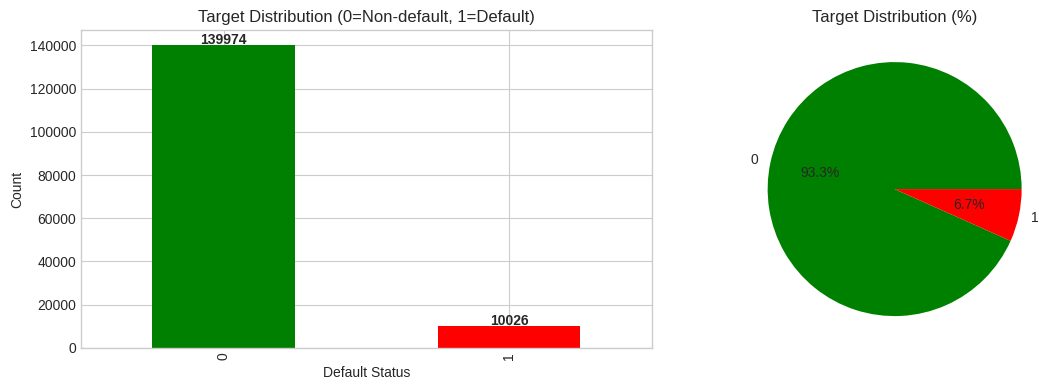

In [ ]:
# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1 = axes[0]
target_dist.plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Target Distribution (0=Non-default, 1=Default)')
ax1.set_xlabel('Default Status')
ax1.set_ylabel('Count')
for i, v in enumerate(target_dist):
    ax1.text(i, v + 500, str(v), ha='center', fontweight='bold')

ax2 = axes[1]
target_perc.plot(kind='pie', autopct='%1.1f%%', ax=ax2, colors=['green', 'red'])
ax2.set_title('Target Distribution (%)')
ax2.set_ylabel('')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### **Summary of Statistics**

In [ ]:
# Summary statistics
print("\n--- Summary Statistics ---")
print(train_data.describe())


--- Summary Statistics ---
              target  revolving_util            age   delinq_30_59  \
count  150000.000000   150000.000000  150000.000000  150000.000000   
mean        0.066840        6.048438      52.295207       0.421033   
std         0.249746      249.755371      14.771866       4.192781   
min         0.000000        0.000000       0.000000       0.000000   
25%         0.000000        0.029867      41.000000       0.000000   
50%         0.000000        0.154181      52.000000       0.000000   
75%         0.000000        0.559046      63.000000       0.000000   
max         1.000000    50708.000000     109.000000      98.000000   

          debt_ratio  monthly_income  num_open_credit      delinq_90  \
count  150000.000000    1.202690e+05    150000.000000  150000.000000   
mean      353.005076    6.670221e+03         8.452760       0.265973   
std      2037.818523    1.438467e+04         5.145951       4.169304   
min         0.000000    0.000000e+00         0.000000

### **Missing Values Check**

In [ ]:
# Check for missing values
print("\n--- Missing Values ---")
missing_data = train_data.isnull().sum()
missing_percent = (missing_data / len(train_data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)


--- Missing Values ---
                Missing Count  Percentage
monthly_income          29731   19.820667
num_dependents           3924    2.616000


### **Missing Values Visualization**

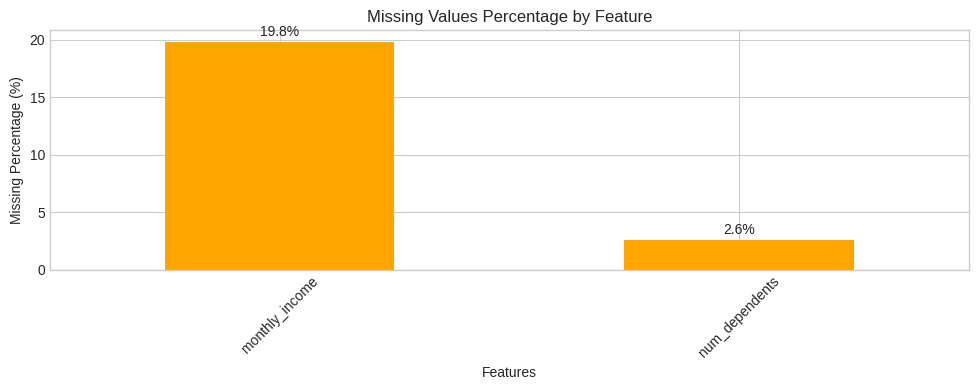

In [ ]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Percentage'].plot(kind='bar', ax=ax, color='orange')
    ax.set_title('Missing Values Percentage by Feature')
    ax.set_xlabel('Features')
    ax.set_ylabel('Missing Percentage (%)')
    ax.set_xticklabels(missing_df.index, rotation=45)
    for i, v in enumerate(missing_df['Percentage']):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
    plt.show()

### **Check for OUtliers**

In [ ]:
# Check for outliers (values 96/98 in delinquency variables)
delinquency_cols = ['delinq_30_59', 'delinq_60_89', 'delinq_90']
print("\n--- Outlier Check (values 96/98) ---")
for col in delinquency_cols:
    if col in train_data.columns:
        outliers = train_data[train_data[col] >= 96][col].count()
        print(f"{col}: {outliers} outliers ({(outliers/len(train_data))*100:.2f}%)")


--- Outlier Check (values 96/98) ---
delinq_30_59: 269 outliers (0.18%)
delinq_60_89: 269 outliers (0.18%)
delinq_90: 269 outliers (0.18%)


### **Correlation Analysis**

In [ ]:
# Correlation analysis
print("\n--- Correlation with Target ---")
correlations = train_data.corr()['target'].sort_values(ascending=False)
print(correlations)


--- Correlation with Target ---
target             1.000000
delinq_30_59       0.125587
delinq_90          0.117175
delinq_60_89       0.102261
num_dependents     0.046048
revolving_util    -0.001802
num_real_estate   -0.007038
debt_ratio        -0.007602
monthly_income    -0.019746
num_open_credit   -0.029669
age               -0.115386
Name: target, dtype: float64


### **Correlation Heatmap**

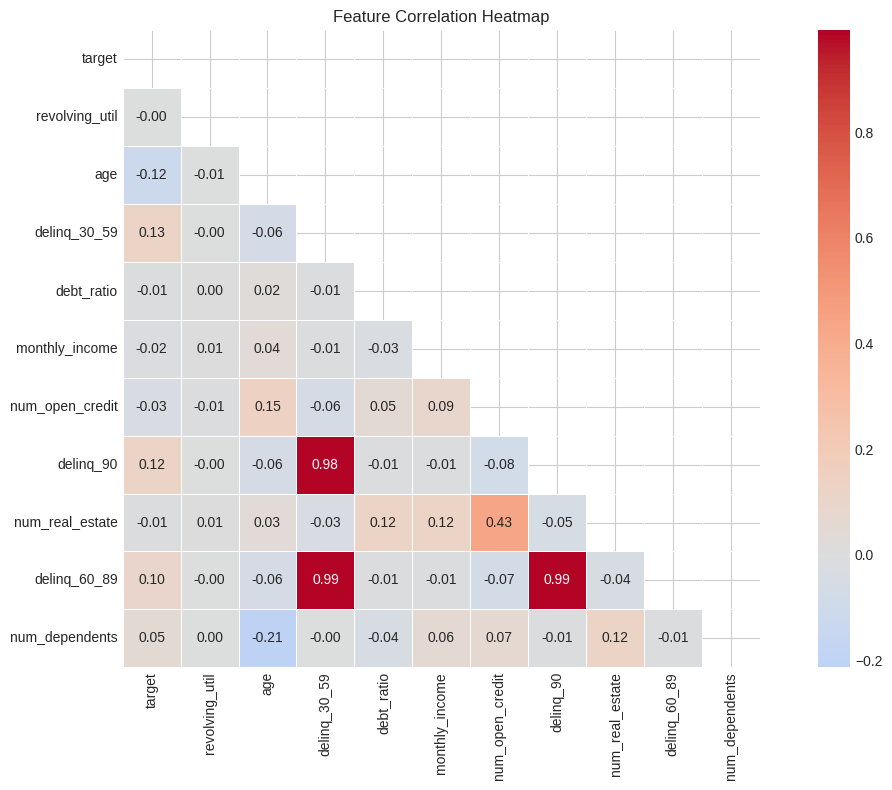

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = train_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### **Distribution of Key Features By Target**

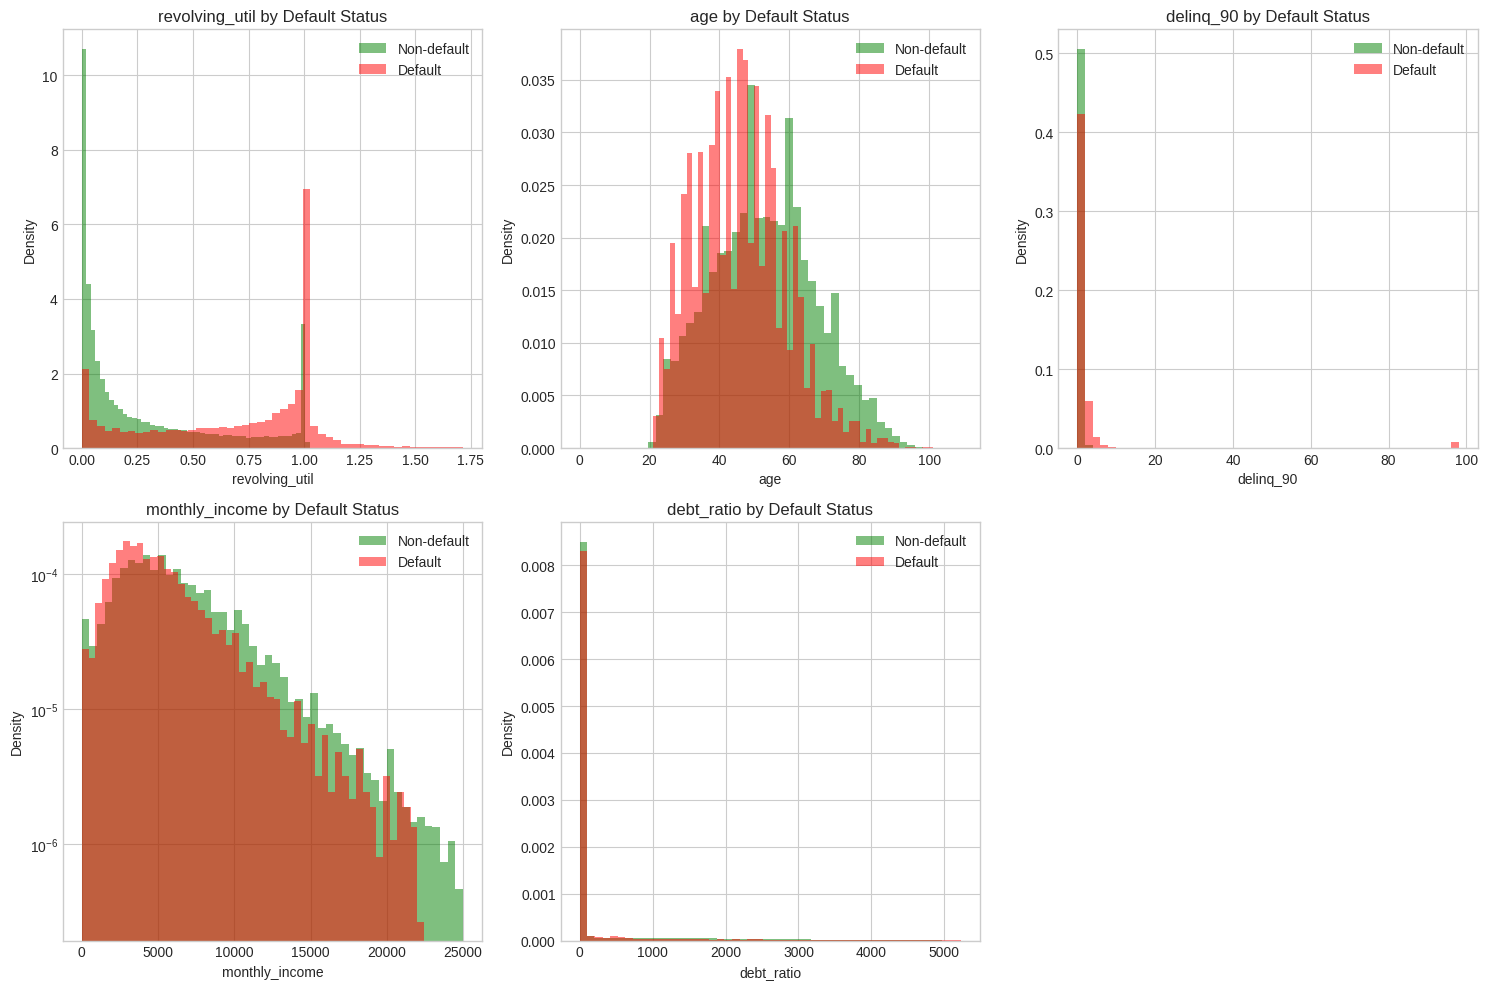

In [ ]:
# Distribution of key features by target
key_features = ['revolving_util', 'age', 'delinq_90', 'monthly_income', 'debt_ratio']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features[:5]):
    if feature in train_data.columns:
        ax = axes[i]
        for target_val, color, label in [(0, 'green', 'Non-default'), (1, 'red', 'Default')]:
            data = train_data[train_data['target'] == target_val][feature].dropna()
            # Cap at 99th percentile for better visualization
            if feature in ['revolving_util', 'debt_ratio', 'monthly_income']:
                data = data[data < data.quantile(0.99)]
            ax.hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.set_title(f'{feature} by Default Status')
        ax.legend()
        ax.set_yscale('log') if feature == 'monthly_income' else None

axes[5].axis('off')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## **DATA PREPROCESSING**

### **Handling of Outliers**

In [ ]:
# -------------------------------
# 5. DATA PREPROCESSING
# -------------------------------

print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Separate features and target
X = train_data.drop('target', axis=1)
y = train_data['target']

# Create a copy for preprocessing
X_processed = X.copy()

# 1. Handle outliers in delinquency variables (replace 96/98 with median)
print("\n--- Handling outliers in delinquency variables ---")
for col in delinquency_cols:
    if col in X_processed.columns:
        outlier_mask = (X_processed[col] >= 96)
        outlier_count = outlier_mask.sum()
        if outlier_count > 0:
            median_val = X_processed[~outlier_mask][col].median()
            X_processed.loc[outlier_mask, col] = median_val
            print(f"{col}: Replaced {outlier_count} outliers with median ({median_val})")


DATA PREPROCESSING

--- Handling outliers in delinquency variables ---
delinq_30_59: Replaced 269 outliers with median (0.0)
delinq_60_89: Replaced 269 outliers with median (0.0)
delinq_90: Replaced 269 outliers with median (0.0)


### **Winsorizing of Extreme Values**

In [ ]:
# 2. Winsorize extreme values (cap at 99th percentile)
print("\n--- Winsorizing continuous variables ---")
continuous_cols = ['revolving_util', 'debt_ratio', 'monthly_income']
for col in continuous_cols:
    if col in X_processed.columns:
        upper_limit = X_processed[col].quantile(0.99)
        X_processed[col] = X_processed[col].clip(upper=upper_limit)
        print(f"{col}: Capped at 99th percentile ({upper_limit:.2f})")


--- Winsorizing continuous variables ---
revolving_util: Capped at 99th percentile (1.09)
debt_ratio: Capped at 99th percentile (4979.00)
monthly_income: Capped at 99th percentile (25000.00)


### **Handling of Missing Values**

In [ ]:
# 3. Handle missing values
print("\n--- Handling missing values ---")

# Monthly income imputation with median
if 'monthly_income' in X_processed.columns:
    income_median = X_processed['monthly_income'].median()
    X_processed['monthly_income'].fillna(income_median, inplace=True)
    print(f"Monthly income: Filled {X['monthly_income'].isnull().sum()} missing values with median ({income_median:.0f})")

# Number of dependents imputation with mode
if 'num_dependents' in X_processed.columns:
    dependents_mode = X_processed['num_dependents'].mode()[0]
    X_processed['num_dependents'].fillna(dependents_mode, inplace=True)
    print(f"Number of dependents: Filled {X['num_dependents'].isnull().sum()} missing values with mode ({dependents_mode})")

# Verify no missing values remain
print(f"\nRemaining missing values: {X_processed.isnull().sum().sum()}")


--- Handling missing values ---
Monthly income: Filled 29731 missing values with median (5400)
Number of dependents: Filled 3924 missing values with mode (0.0)

Remaining missing values: 0


### **Creation of Additional Features**

In [ ]:
# 4. Create additional features (feature engineering)
print("\n--- Feature engineering ---")

# Income to debt ratio (inverse of debt_ratio)
X_processed['income_to_debt'] = X_processed['monthly_income'] / (X_processed['debt_ratio'] + 0.001)

# Total delinquency count
X_processed['total_delinquencies'] = (X_processed['delinq_30_59'] +
                                       X_processed['delinq_60_89'] +
                                       X_processed['delinq_90'])

# Has any delinquency flag
X_processed['has_delinquency'] = (X_processed['total_delinquencies'] > 0).astype(int)

print("Created new features: income_to_debt, total_delinquencies, has_delinquency")

# Update feature list
feature_names = X_processed.columns.tolist()
print(f"\nFinal feature set ({len(feature_names)} features): {feature_names}")



--- Feature engineering ---
Created new features: income_to_debt, total_delinquencies, has_delinquency

Final feature set (13 features): ['revolving_util', 'age', 'delinq_30_59', 'debt_ratio', 'monthly_income', 'num_open_credit', 'delinq_90', 'num_real_estate', 'delinq_60_89', 'num_dependents', 'income_to_debt', 'total_delinquencies', 'has_delinquency']


### **Dataset Split to Train-Test**

In [ ]:
# 5. Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- Train/Validation Split ---")
print(f"Training set: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% defaults)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean()*100:.2f}% defaults)")


--- Train/Validation Split ---
Training set: 120000 samples (6.68% defaults)
Validation set: 30000 samples (6.68% defaults)


In [ ]:
# 6. Prepare test data (apply same preprocessing)
X_test = test_data.copy()

# Apply same preprocessing to test data
for col in delinquency_cols:
    if col in X_test.columns:
        X_test.loc[X_test[col] >= 96, col] = X_processed[~outlier_mask][col].median()

for col in continuous_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].clip(upper=X_processed[col].quantile(0.99))

# Handle missing values in test
if 'monthly_income' in X_test.columns:
    X_test['monthly_income'].fillna(income_median, inplace=True)
if 'num_dependents' in X_test.columns:
    X_test['num_dependents'].fillna(dependents_mode, inplace=True)

# Add engineered features to test
X_test['income_to_debt'] = X_test['monthly_income'] / (X_test['debt_ratio'] + 0.001)
X_test['total_delinquencies'] = (X_test['delinq_30_59'] +
                                  X_test['delinq_60_89'] +
                                  X_test['delinq_90'])
X_test['has_delinquency'] = (X_test['total_delinquencies'] > 0).astype(int)

## **FEATURES SCALING**

In [ ]:
# -------------------------------
# 6. SCALE FEATURES (for models that need it)
# -------------------------------

# For logistic regression and neural network, we need scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# For tree-based models, we keep original (unscaled) features
X_train_tree = X_train.values
X_val_tree = X_val.values
X_test_tree = X_test.values

# Convert to DataFrame for easier handling later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print("\n--- Feature Scaling Completed ---")
print(f"Scaled features shape: {X_train_scaled.shape}")


--- Feature Scaling Completed ---
Scaled features shape: (120000, 13)

--- Applying SMOTE ---
After SMOTE - Class 0: 111979, Class 1: 111979

--- Applying Random Undersampling ---
After Undersampling - Class 0: 8021, Class 1: 8021

--- Class Weights ---
Class weights: Non-default: 1.00, Default: 7.48


## **HANDLING CLASS IMBALANCE**

In [ ]:
# -------------------------------
# 7. HANDLE CLASS IMBALANCE
# -------------------------------

print("\n" + "="*60)
print("CLASS IMBALANCE HANDLING")
print("="*60)

# Option 1: SMOTE (Synthetic Minority Oversampling)
print("\n--- Applying SMOTE ---")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE - Class 0: {sum(y_train_smote==0)}, Class 1: {sum(y_train_smote==1)}")

# Option 2: Undersampling
print("\n--- Applying Random Undersampling ---")
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)
print(f"After Undersampling - Class 0: {sum(y_train_under==0)}, Class 1: {sum(y_train_under==1)}")

# Option 3: Class weights (we'll use this as primary method)
class_weight = {0: 1, 1: (len(y_train) / (2 * sum(y_train==1)))}
print(f"\n--- Class Weights ---")
print(f"Class weights: Non-default: {class_weight[0]:.2f}, Default: {class_weight[1]:.2f}")


CLASS IMBALANCE HANDLING

--- Applying SMOTE ---
After SMOTE - Class 0: 111979, Class 1: 111979

--- Applying Random Undersampling ---
After Undersampling - Class 0: 8021, Class 1: 8021

--- Class Weights ---
Class weights: Non-default: 1.00, Default: 7.48


## **MODEL TRAINING FUNCTION**

In [ ]:
# -------------------------------
# 8. MODEL TRAINING FUNCTION
# -------------------------------

def train_and_evaluate_model(model, model_name, X_train_data, y_train_data,
                             X_val_data, y_val_data, X_test_data=None):
    """
    Train a model and evaluate on validation set
    """
    print(f"\n{'-'*50}")
    print(f"Training {model_name}...")
    print(f"{'-'*50}")

    # Train the model
    model.fit(X_train_data, y_train_data)

    # Make predictions
    y_pred_train = model.predict(X_train_data)
    y_pred_val = model.predict(X_val_data)

    # Get probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_proba_train = model.predict_proba(X_train_data)[:, 1]
        y_proba_val = model.predict_proba(X_val_data)[:, 1]
    else:
        y_proba_train = None
        y_proba_val = None

    # Calculate metrics
    metrics = {}

    # Training metrics
    metrics['train_accuracy'] = accuracy_score(y_train_data, y_pred_train)
    metrics['train_precision'] = precision_score(y_train_data, y_pred_train, zero_division=0)
    metrics['train_recall'] = recall_score(y_train_data, y_pred_train, zero_division=0)
    metrics['train_f1'] = f1_score(y_train_data, y_pred_train, zero_division=0)
    metrics['train_auc'] = roc_auc_score(y_train_data, y_proba_train) if y_proba_train is not None else None

    # Validation metrics
    metrics['val_accuracy'] = accuracy_score(y_val_data, y_pred_val)
    metrics['val_precision'] = precision_score(y_val_data, y_pred_val, zero_division=0)
    metrics['val_recall'] = recall_score(y_val_data, y_pred_val, zero_division=0)
    metrics['val_f1'] = f1_score(y_val_data, y_pred_val, zero_division=0)
    metrics['val_auc'] = roc_auc_score(y_val_data, y_proba_val) if y_proba_val is not None else None
    metrics['confusion_matrix'] = confusion_matrix(y_val_data, y_pred_val)

    # Print results
    print(f"\n{model_name} - Training Results:")
    print(f"  Accuracy:  {metrics['train_accuracy']:.4f}")
    print(f"  Precision: {metrics['train_precision']:.4f}")
    print(f"  Recall:    {metrics['train_recall']:.4f}")
    print(f"  F1-Score:  {metrics['train_f1']:.4f}")
    if metrics['train_auc']:
        print(f"  AUC:       {metrics['train_auc']:.4f}")

    print(f"\n{model_name} - Validation Results:")
    print(f"  Accuracy:  {metrics['val_accuracy']:.4f}")
    print(f"  Precision: {metrics['val_precision']:.4f}")
    print(f"  Recall:    {metrics['val_recall']:.4f}")
    print(f"  F1-Score:  {metrics['val_f1']:.4f}")
    if metrics['val_auc']:
        print(f"  AUC:       {metrics['val_auc']:.4f}")

    print(f"\nConfusion Matrix (Validation):")
    print(metrics['confusion_matrix'])

    # Store the model and predictions
    metrics['model'] = model
    metrics['y_pred_val'] = y_pred_val
    metrics['y_proba_val'] = y_proba_val

    # Test predictions if provided
    if X_test_data is not None:
        y_pred_test = model.predict(X_test_data)
        if hasattr(model, "predict_proba"):
            y_proba_test = model.predict_proba(X_test_data)[:, 1]
        else:
            y_proba_test = None
        metrics['y_pred_test'] = y_pred_test
        metrics['y_proba_test'] = y_proba_test

    return metrics

## **TRAINING ALL MODELS**

### **1. Logistic Regression Model**

In [ ]:
# -------------------------------
# 9. TRAIN ALL MODELS
# -------------------------------

print("\n" + "="*60)
print("TRAINING ALL MODELS")
print("="*60)

# Dictionary to store all results
results = {}

# ----- MODEL 1: Logistic Regression (Baseline) -----
print("\n" + "="*30)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*30)

# Hyperparameter tuning for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_base = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
grid_lr = GridSearchCV(lr_base, param_grid_lr, cv=3, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best cross-val AUC: {grid_lr.best_score_:.4f}")

# Train best model
lr_best = grid_lr.best_estimator_
results['Logistic Regression'] = train_and_evaluate_model(
    lr_best, "Logistic Regression",
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled
)


TRAINING ALL MODELS

MODEL 1: LOGISTIC REGRESSION
Best parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-val AUC: 0.8162

--------------------------------------------------
Training Logistic Regression...
--------------------------------------------------

Logistic Regression - Training Results:
  Accuracy:  0.8269
  Precision: 0.2256
  Recall:    0.6534
  F1-Score:  0.3354
  AUC:       0.8168

Logistic Regression - Validation Results:
  Accuracy:  0.8298
  Precision: 0.2299
  Recall:    0.6579
  F1-Score:  0.3407
  AUC:       0.8239

Confusion Matrix (Validation):
[[23576  4419]
 [  686  1319]]


### **2. Decision Tree Model**

In [ ]:

# ----- MODEL 2: Decision Tree -----
print("\n" + "="*30)
print("MODEL 2: DECISION TREE")
print("="*30)

# Hyperparameter tuning for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_dt = GridSearchCV(dt_base, param_grid_dt, cv=3, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train_tree, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best cross-val AUC: {grid_dt.best_score_:.4f}")

# Train best model
dt_best = grid_dt.best_estimator_
results['Decision Tree'] = train_and_evaluate_model(
    dt_best, "Decision Tree",
    X_train_tree, y_train,
    X_val_tree, y_val,
    X_test_tree
)


MODEL 2: DECISION TREE
Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best cross-val AUC: 0.8497

--------------------------------------------------
Training Decision Tree...
--------------------------------------------------

Decision Tree - Training Results:
  Accuracy:  0.7755
  Precision: 0.1997
  Recall:    0.7837
  F1-Score:  0.3182
  AUC:       0.8552

Decision Tree - Validation Results:
  Accuracy:  0.7739
  Precision: 0.1989
  Recall:    0.7870
  F1-Score:  0.3175
  AUC:       0.8530

Confusion Matrix (Validation):
[[21638  6357]
 [  427  1578]]


### **3. Random Forest Model**

In [ ]:
# ----- MODEL 3: Random Forest -----
print("\n" + "="*30)
print("MODEL 3: RANDOM FOREST")
print("="*30)

# Hyperparameter tuning for Random Forest (limited grid for speed)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(rf_base, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_tree, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best cross-val AUC: {grid_rf.best_score_:.4f}")

# Train best model
rf_best = grid_rf.best_estimator_
results['Random Forest'] = train_and_evaluate_model(
    rf_best, "Random Forest",
    X_train_tree, y_train,
    X_val_tree, y_val,
    X_test_tree
)


MODEL 3: RANDOM FOREST
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-val AUC: 0.8586

--------------------------------------------------
Training Random Forest...
--------------------------------------------------

Random Forest - Training Results:
  Accuracy:  0.8373
  Precision: 0.2610
  Recall:    0.7836
  F1-Score:  0.3916
  AUC:       0.8955

Random Forest - Validation Results:
  Accuracy:  0.8293
  Precision: 0.2423
  Recall:    0.7307
  F1-Score:  0.3640
  AUC:       0.8654

Confusion Matrix (Validation):
[[23415  4580]
 [  540  1465]]


### **4. Gradient Boosting Model**

In [ ]:
# ----- MODEL 4: Gradient Boosting -----
print("\n" + "="*30)
print("MODEL 4: GRADIENT BOOSTING")
print("="*30)

# Hyperparameter tuning for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [5, 10]
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb_base, param_grid_gb, cv=3, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train_tree, y_train)

print(f"Best parameters: {grid_gb.best_params_}")
print(f"Best cross-val AUC: {grid_gb.best_score_:.4f}")

# Train best model
gb_best = grid_gb.best_estimator_
results['Gradient Boosting'] = train_and_evaluate_model(
    gb_best, "Gradient Boosting",
    X_train_tree, y_train,
    X_val_tree, y_val,
    X_test_tree
)


MODEL 4: GRADIENT BOOSTING
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Best cross-val AUC: 0.8629

--------------------------------------------------
Training Gradient Boosting...
--------------------------------------------------

Gradient Boosting - Training Results:
  Accuracy:  0.9402
  Precision: 0.6738
  Recall:    0.2032
  F1-Score:  0.3123
  AUC:       0.8718

Gradient Boosting - Validation Results:
  Accuracy:  0.9374
  Precision: 0.6036
  Recall:    0.1860
  F1-Score:  0.2844
  AUC:       0.8681

Confusion Matrix (Validation):
[[27750   245]
 [ 1632   373]]


### **5. XGBoot Model**

In [ ]:
# ----- MODEL 5: XGBoost -----
print("\n" + "="*30)
print("MODEL 5: XGBOOST")
print("="*30)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Hyperparameter tuning for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight,
                             eval_metric='auc', use_label_encoder=False)
grid_xgb = GridSearchCV(xgb_base, param_grid_xgb, cv=3, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_tree, y_train)

print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best cross-val AUC: {grid_xgb.best_score_:.4f}")

# Train best model
xgb_best = grid_xgb.best_estimator_
results['XGBoost'] = train_and_evaluate_model(
    xgb_best, "XGBoost",
    X_train_tree, y_train,
    X_val_tree, y_val,
    X_test_tree
)


MODEL 5: XGBOOST
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best cross-val AUC: 0.8638

--------------------------------------------------
Training XGBoost...
--------------------------------------------------

XGBoost - Training Results:
  Accuracy:  0.7915
  Precision: 0.2138
  Recall:    0.7917
  F1-Score:  0.3367
  AUC:       0.8706

XGBoost - Validation Results:
  Accuracy:  0.7907
  Precision: 0.2132
  Recall:    0.7920
  F1-Score:  0.3359
  AUC:       0.8685

Confusion Matrix (Validation):
[[22134  5861]
 [  417  1588]]


### **6. Neural Network Model**

In [ ]:
# ----- MODEL 6: Neural Network -----
print("\n" + "="*30)
print("MODEL 6: NEURAL NETWORK")
print("="*30)

# Hyperparameter tuning for Neural Network
param_grid_nn = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [256, 512]
}

nn_base = MLPClassifier(random_state=42, max_iter=500, early_stopping=True)
grid_nn = GridSearchCV(nn_base, param_grid_nn, cv=2, scoring='roc_auc', n_jobs=-1)
grid_nn.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_nn.best_params_}")
print(f"Best cross-val AUC: {grid_nn.best_score_:.4f}")

# Train best model
nn_best = grid_nn.best_estimator_
results['Neural Network'] = train_and_evaluate_model(
    nn_best, "Neural Network",
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled
)


MODEL 6: NEURAL NETWORK
Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 256, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Best cross-val AUC: 0.8308

--------------------------------------------------
Training Neural Network...
--------------------------------------------------

Neural Network - Training Results:
  Accuracy:  0.9367
  Precision: 0.5782
  Recall:    0.1949
  F1-Score:  0.2915
  AUC:       0.8303

Neural Network - Validation Results:
  Accuracy:  0.9361
  Precision: 0.5688
  Recall:    0.1835
  F1-Score:  0.2775
  AUC:       0.8327

Confusion Matrix (Validation):
[[27716   279]
 [ 1637   368]]


## **MODEL PERFORMANCE COMPARISON**

In [ ]:
# -------------------------------
# 10. COMPARE MODEL PERFORMANCE
# -------------------------------

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

# Create comparison dataframe
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': metrics['val_accuracy'],
        'Precision': metrics['val_precision'],
        'Recall': metrics['val_recall'],
        'F1-Score': metrics['val_f1'],
        'AUC-ROC': metrics['val_auc']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False)
print("\n--- Model Performance Comparison (Validation Set) ---")
print(comparison_df.to_string(index=False))


MODEL PERFORMANCE COMPARISON

--- Model Performance Comparison (Validation Set) ---
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
            XGBoost  0.790733   0.213183 0.792020  0.335942 0.868537
  Gradient Boosting  0.937433   0.603560 0.186035  0.284407 0.868082
      Random Forest  0.829333   0.242349 0.730673  0.363975 0.865386
      Decision Tree  0.773867   0.198866 0.787032  0.317505 0.853040
     Neural Network  0.936133   0.568779 0.183541  0.277526 0.832717
Logistic Regression  0.829833   0.229871 0.657855  0.340695 0.823893


In [ ]:
# Save comparison to CSV
comparison_df.to_csv('model_comparison.csv', index=False)

### **Visualize Model Comparison**

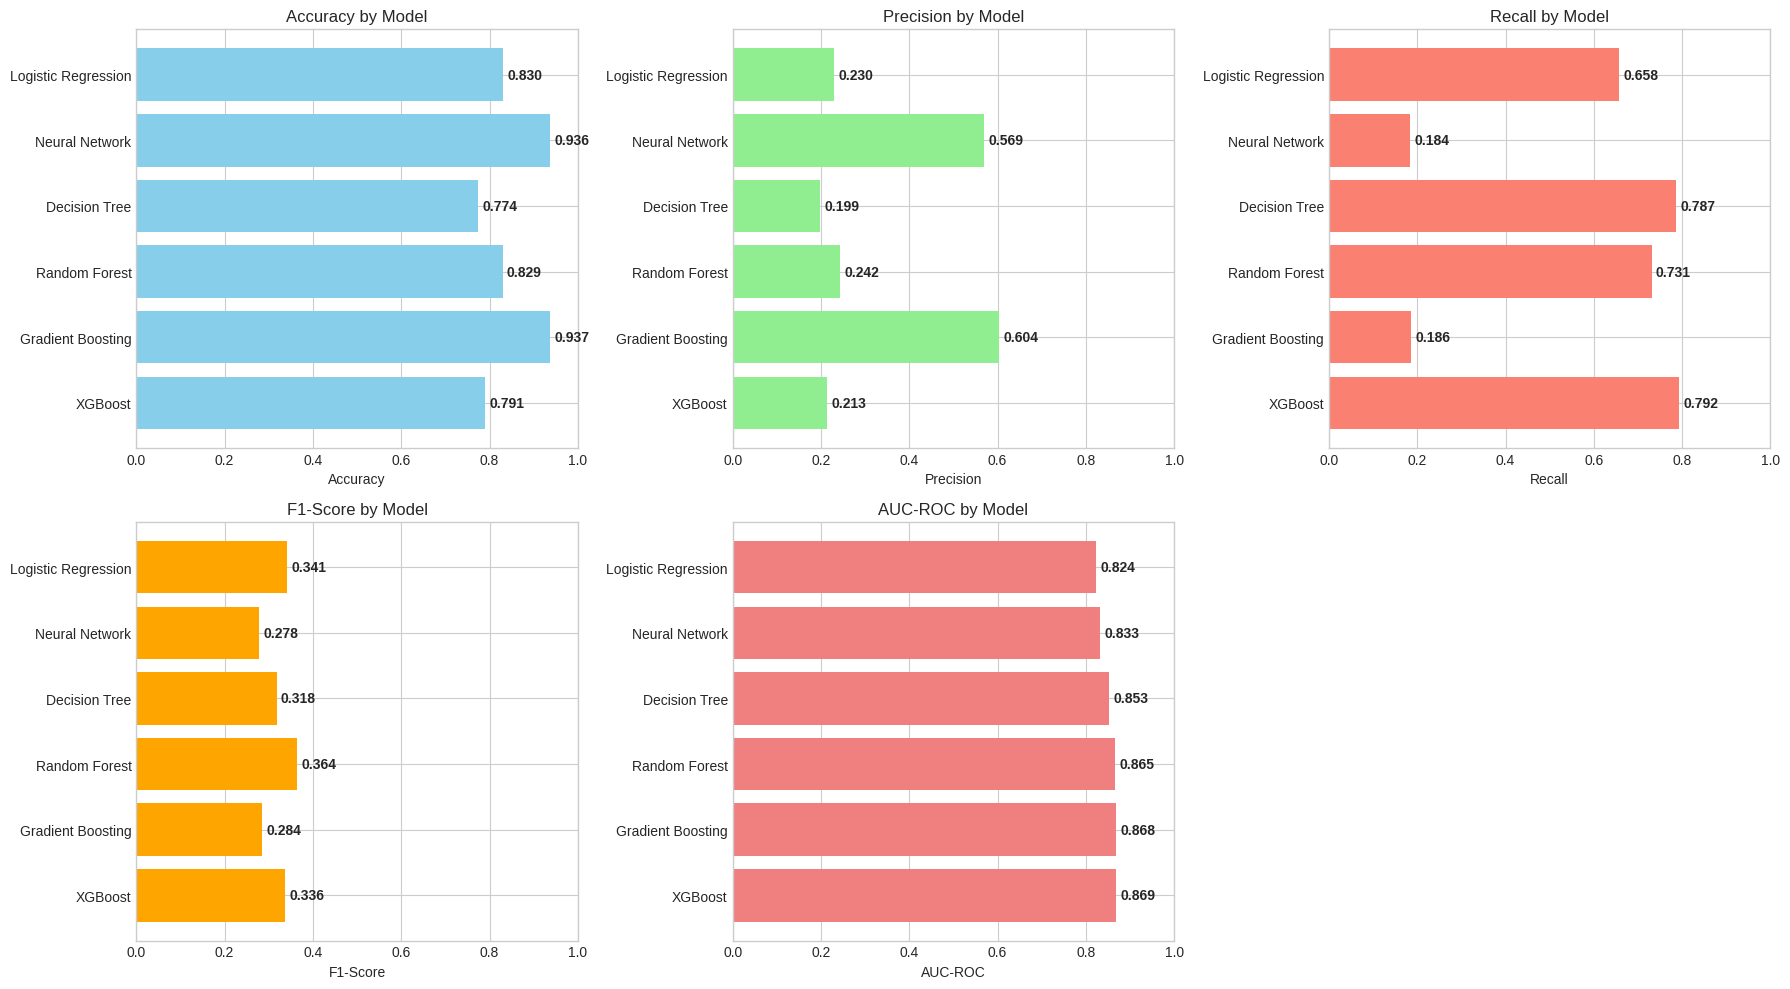

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'lightcoral']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    models = comparison_df['Model'].values
    values = comparison_df[metric].values

    bars = ax.barh(models, values, color=colors[i])
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.set_xlim(0, 1.0)

    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', fontweight='bold')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### **ROC Curves**

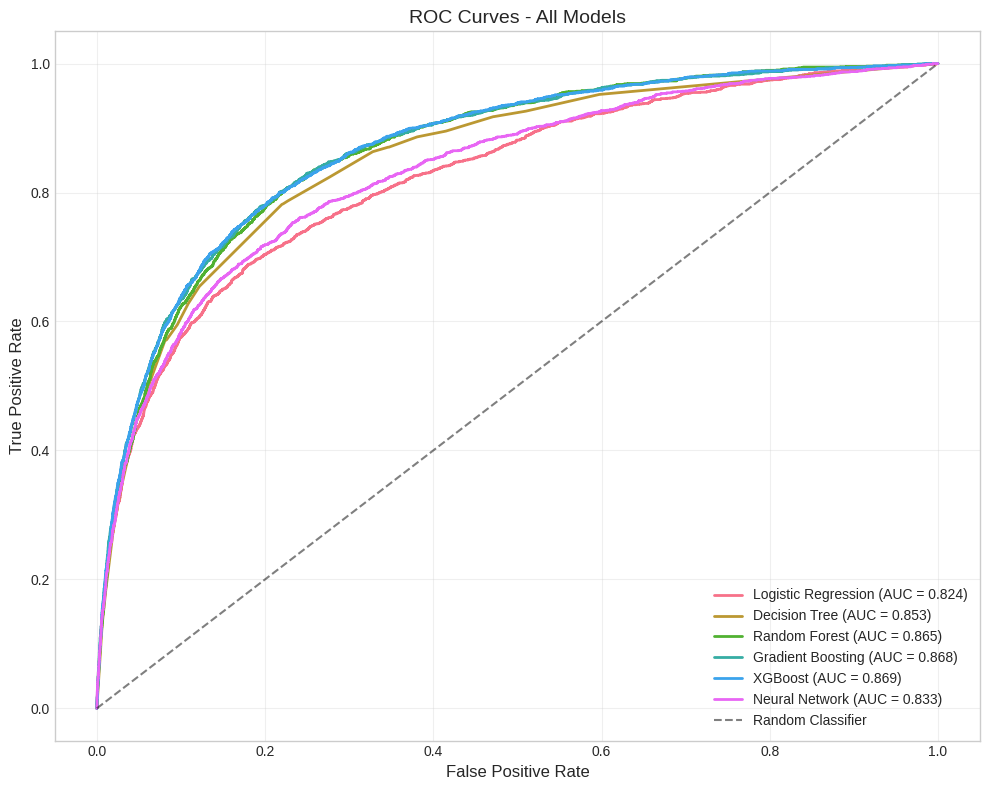

In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, metrics in results.items():
    if metrics['y_proba_val'] is not None:
        fpr, tpr, _ = roc_curve(y_val, metrics['y_proba_val'])
        auc = metrics['val_auc']
        ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

# Plot diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### **Precision-Recall Curves**

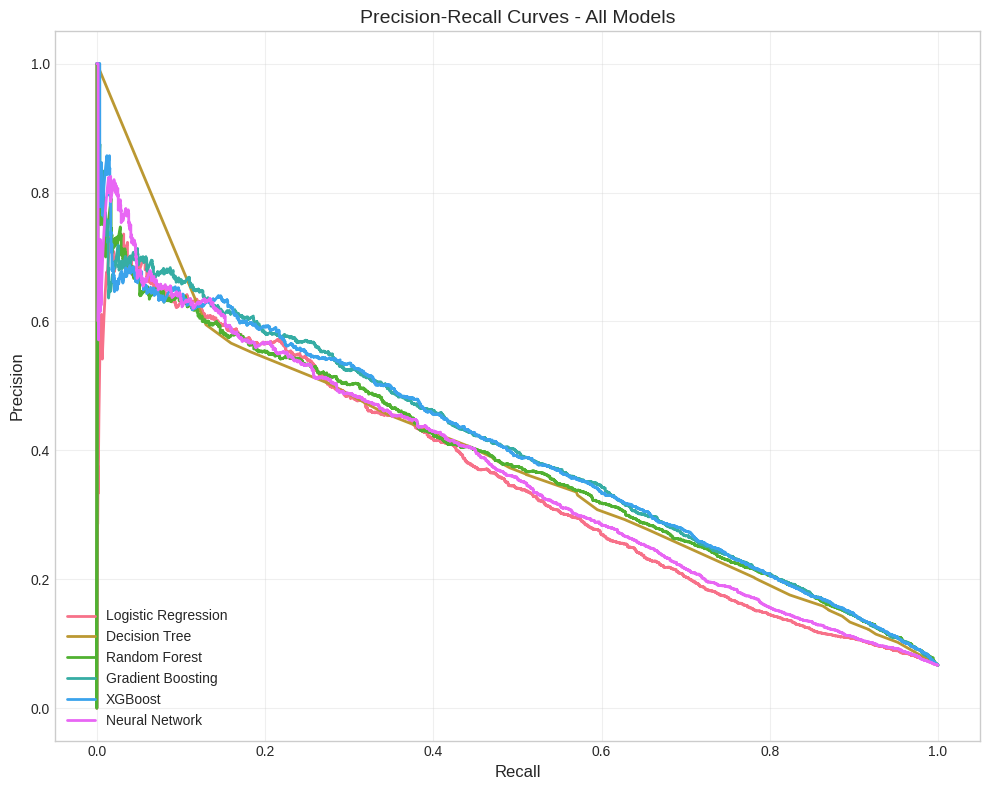

In [ ]:
# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, metrics in results.items():
    if metrics['y_proba_val'] is not None:
        precision_vals, recall_vals, _ = precision_recall_curve(y_val, metrics['y_proba_val'])
        # Calculate AUC-PR
        pr_auc = metrics['val_auc']  # We don't have PR AUC calculated yet
        ax.plot(recall_vals, precision_vals, label=f'{model_name}', linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models', fontsize=14)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## **FEATURE IMPORTANCE ANALYSIS**

### **1. Random Forest**

In [ ]:
# -------------------------------
# 11. FEATURE IMPORTANCE ANALYSIS
# -------------------------------

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Collect feature importance from tree-based models
feature_importance_dict = {}

# Random Forest
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    feature_importance_dict['Random Forest'] = rf_importance
    print("\n--- Random Forest Feature Importance ---")
    print(rf_importance)


FEATURE IMPORTANCE ANALYSIS

--- Random Forest Feature Importance ---
                feature  importance
0        revolving_util    0.249262
11  total_delinquencies    0.177424
12      has_delinquency    0.175743
6             delinq_90    0.080036
2          delinq_30_59    0.058850
1                   age    0.051959
8          delinq_60_89    0.041699
5       num_open_credit    0.039632
3            debt_ratio    0.037098
10       income_to_debt    0.033171
4        monthly_income    0.028557
7       num_real_estate    0.019535
9        num_dependents    0.007036


### **2. XGBoost**

In [ ]:
# XGBoost
if 'XGBoost' in results:
    xgb_model = results['XGBoost']['model']
    xgb_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    feature_importance_dict['XGBoost'] = xgb_importance
    print("\n--- XGBoost Feature Importance ---")
    print(xgb_importance)


--- XGBoost Feature Importance ---
                feature  importance
11  total_delinquencies    0.546864
0        revolving_util    0.168865
6             delinq_90    0.068143
8          delinq_60_89    0.041082
7       num_real_estate    0.036214
2          delinq_30_59    0.027959
1                   age    0.026213
5       num_open_credit    0.025652
10       income_to_debt    0.017160
3            debt_ratio    0.016862
4        monthly_income    0.016202
9        num_dependents    0.008783
12      has_delinquency    0.000000


### **3. Gradient Boosting**

In [ ]:
# Gradient Boosting
if 'Gradient Boosting' in results:
    gb_model = results['Gradient Boosting']['model']
    gb_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    feature_importance_dict['Gradient Boosting'] = gb_importance
    print("\n--- Gradient Boosting Feature Importance ---")
    print(gb_importance)


--- Gradient Boosting Feature Importance ---
                feature  importance
11  total_delinquencies    0.548223
0        revolving_util    0.179068
6             delinq_90    0.083788
12      has_delinquency    0.033280
1                   age    0.025686
5       num_open_credit    0.024589
3            debt_ratio    0.021333
10       income_to_debt    0.017419
2          delinq_30_59    0.016987
4        monthly_income    0.016938
8          delinq_60_89    0.015809
7       num_real_estate    0.012864
9        num_dependents    0.004017


### **4. Logistic Regression**

In [ ]:
# Logistic Regression coefficients (absolute values)
if 'Logistic Regression' in results:
    lr_model = results['Logistic Regression']['model']
    lr_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(lr_model.coef_[0])
    }).sort_values('importance', ascending=False)
    feature_importance_dict['Logistic Regression'] = lr_importance
    print("\n--- Logistic Regression Coefficient Magnitudes ---")
    print(lr_importance)


--- Logistic Regression Coefficient Magnitudes ---
                feature  importance
12      has_delinquency    0.474564
1                   age    0.442998
4        monthly_income    0.339598
6             delinq_90    0.323623
10       income_to_debt    0.297237
8          delinq_60_89    0.174087
11  total_delinquencies    0.161639
7       num_real_estate    0.136486
3            debt_ratio    0.125023
2          delinq_30_59    0.091339
9        num_dependents    0.037539
5       num_open_credit    0.022363
0        revolving_util    0.003871


### **Consensus Importance Ranking**


--- Consensus Feature Importance (Averaged Across Models) ---
                     Random Forest   XGBoost  Gradient Boosting  \
feature                                                           
total_delinquencies       0.177424  0.546864           0.548223   
revolving_util            0.249262  0.168865           0.179068   
has_delinquency           0.175743  0.000000           0.033280   
delinq_90                 0.080036  0.068143           0.083788   
age                       0.051959  0.026213           0.025686   
monthly_income            0.028557  0.016202           0.016938   
income_to_debt            0.033171  0.017160           0.017419   
delinq_60_89              0.041699  0.041082           0.015809   
delinq_30_59              0.058850  0.027959           0.016987   
debt_ratio                0.037098  0.016862           0.021333   
num_real_estate           0.019535  0.036214           0.012864   
num_open_credit           0.039632  0.025652           0.024589   

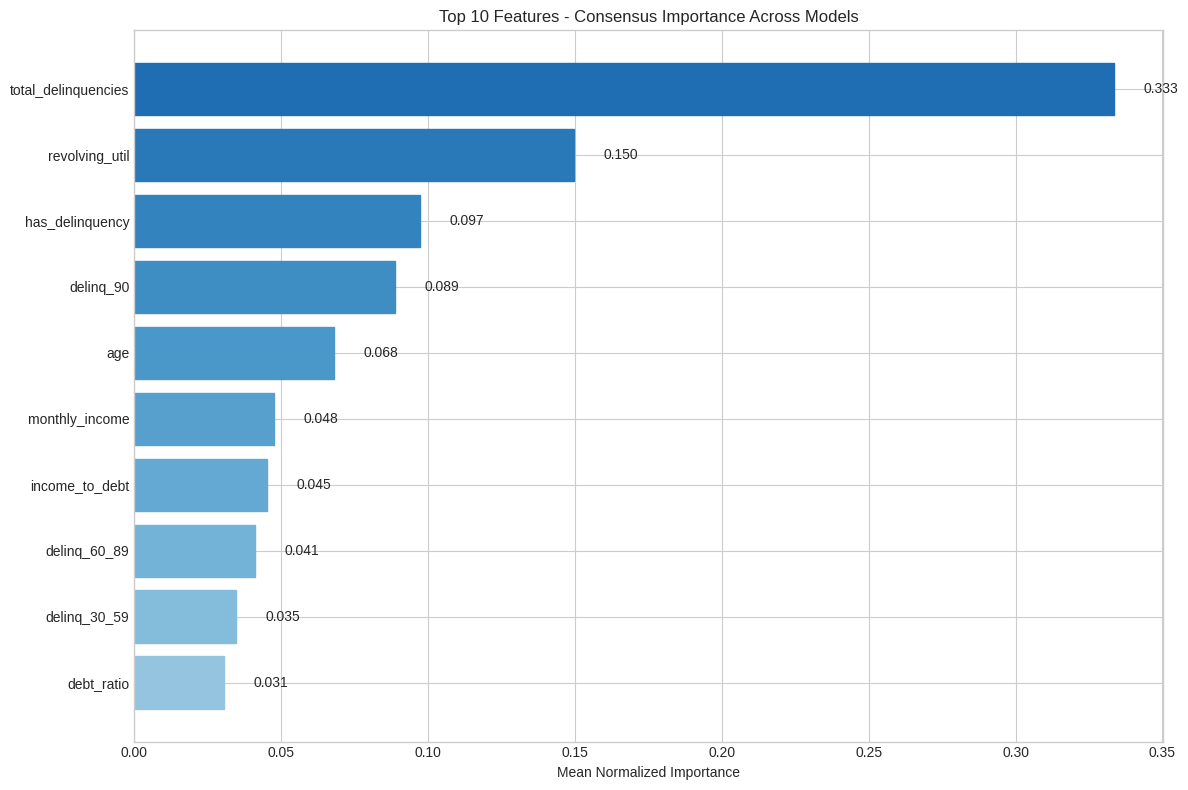

In [ ]:
# Create consensus importance ranking
if feature_importance_dict:
    # Average importance across models
    importance_df = pd.DataFrame()
    for model_name, imp_df in feature_importance_dict.items():
        # Normalize importance to sum to 1
        normalized = imp_df.set_index('feature')['importance'] / imp_df['importance'].sum()
        importance_df[model_name] = normalized

    # Add mean and rank
    importance_df['mean_importance'] = importance_df.mean(axis=1)
    importance_df = importance_df.sort_values('mean_importance', ascending=False)

    print("\n--- Consensus Feature Importance (Averaged Across Models) ---")
    print(importance_df)

    # Plot consensus importance
    fig, ax = plt.subplots(figsize=(12, 8))

    top_features = importance_df.head(10).index
    top_importance = importance_df.loc[top_features, 'mean_importance']

    bars = ax.barh(range(len(top_features)), top_importance.values[::-1])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features[::-1])
    ax.set_xlabel('Mean Normalized Importance')
    ax.set_title('Top 10 Features - Consensus Importance Across Models')

    # Color bars based on importance
    for i, (bar, val) in enumerate(zip(bars, top_importance.values[::-1])):
        bar.set_color(plt.cm.Blues(0.4 + 0.4 * (i / len(top_features))))
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center')

    plt.tight_layout()
    plt.savefig('consensus_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

## **SHAP ANALYSIS**

***Done only for the best model - XGBoost***


SHAP ANALYSIS (XGBOOST)

Creating SHAP explainer (this may take a few minutes)...

Generating SHAP summary plot...


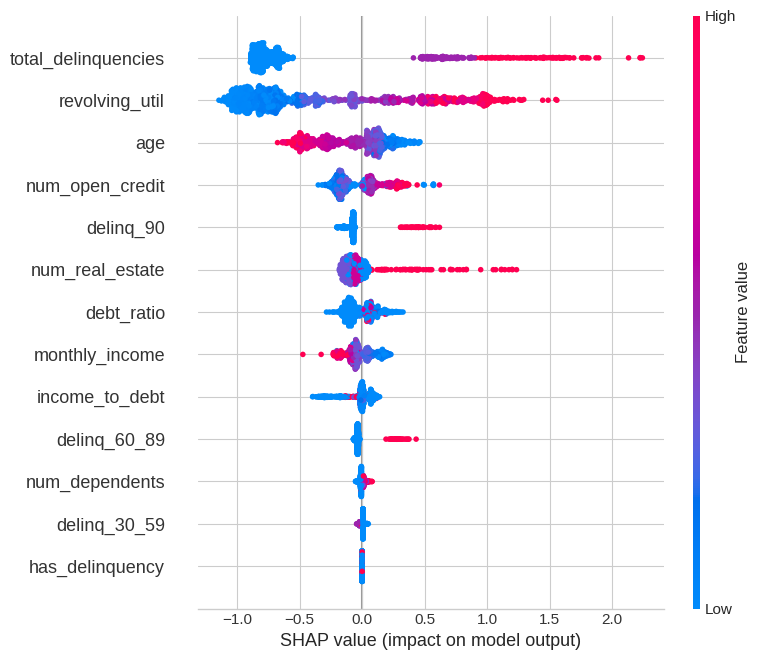


Generating SHAP bar plot...


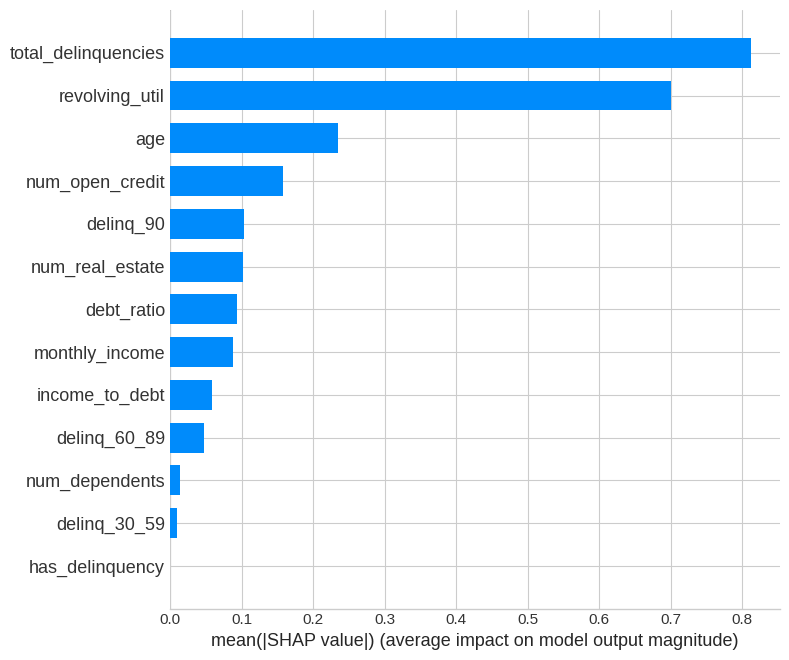


SHAP dependence plot for total_delinquencies...


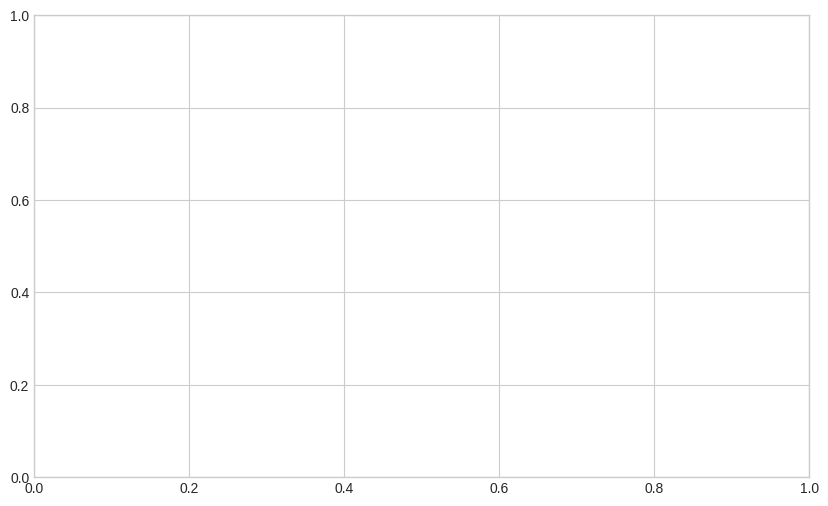

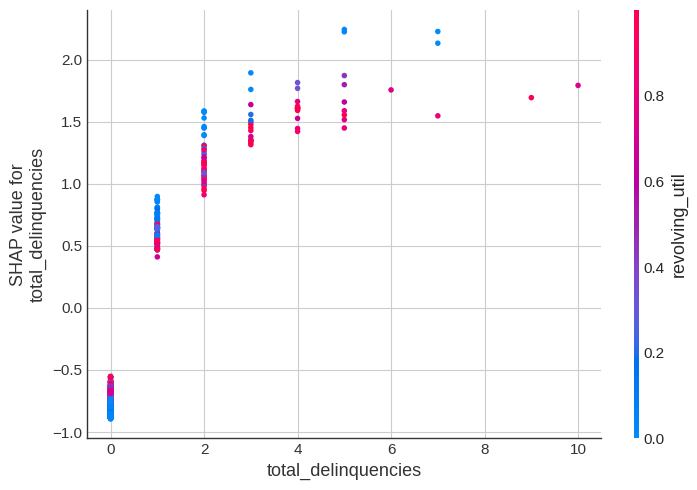


SHAP dependence plot for revolving_util...


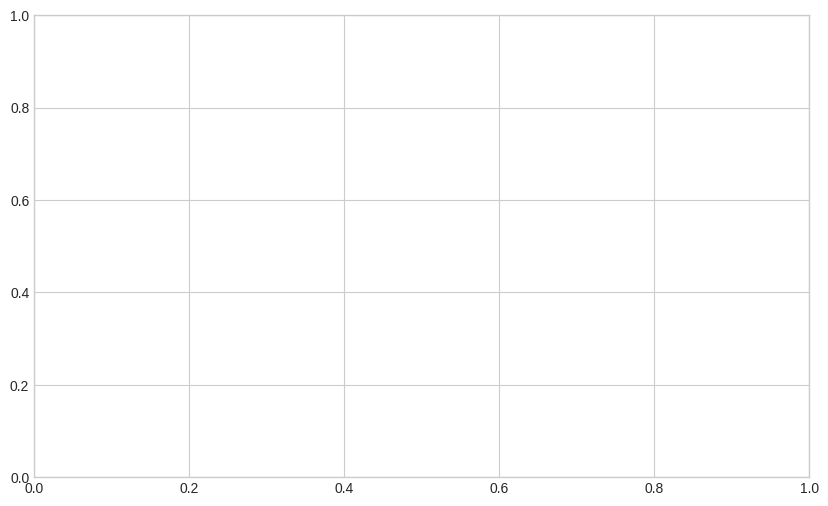

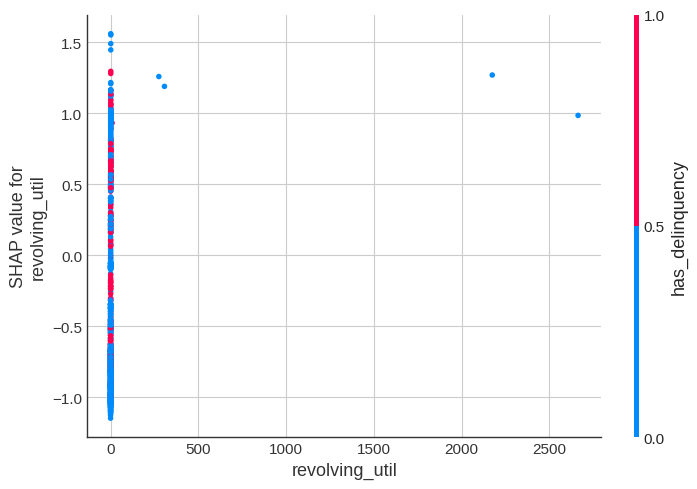


SHAP dependence plot for has_delinquency...


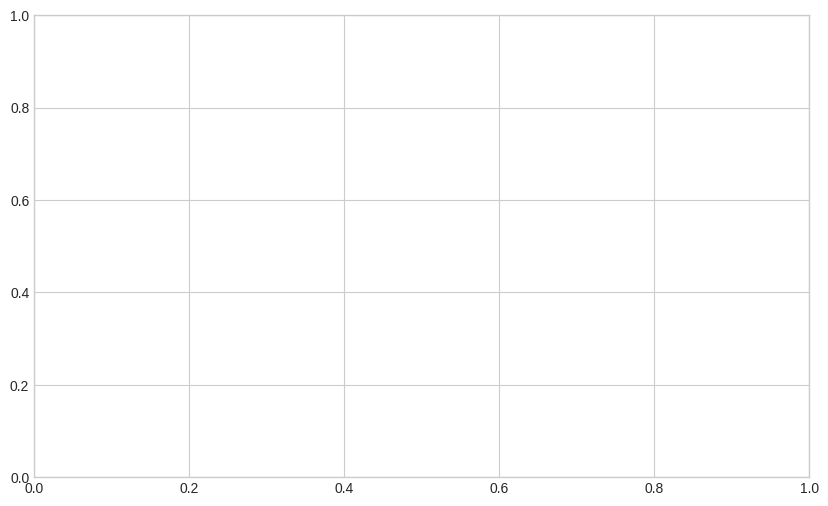

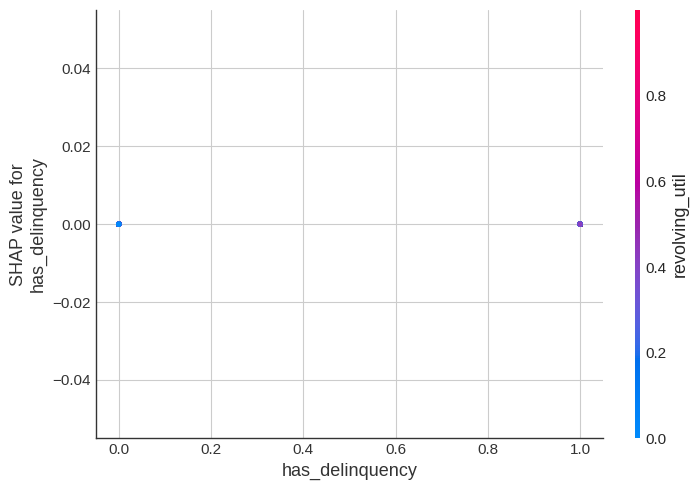


Generating force plots for individual predictions...


<Figure size 640x480 with 0 Axes>

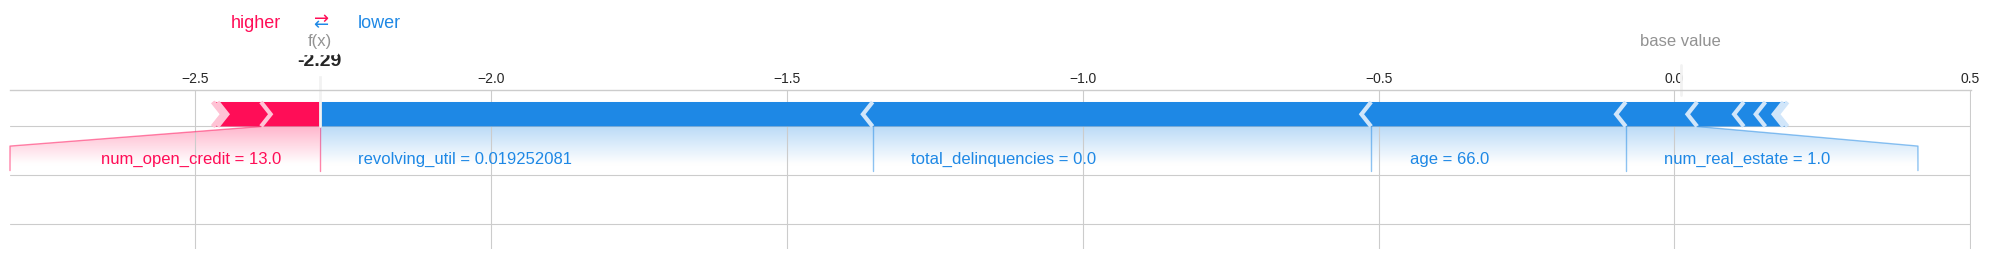

Sample 1: Actual=0, Predicted Probability=0.0920


<Figure size 640x480 with 0 Axes>

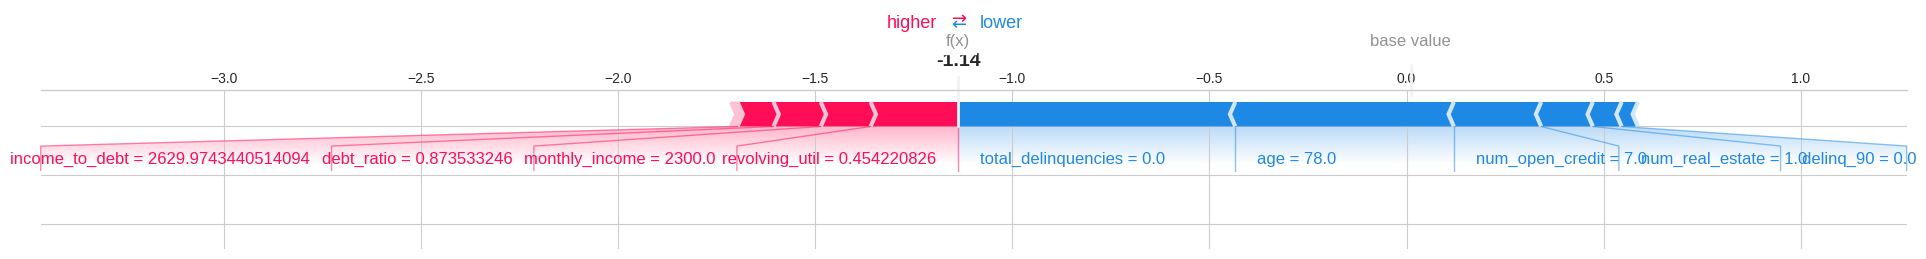

Sample 2: Actual=0, Predicted Probability=0.2428


<Figure size 640x480 with 0 Axes>

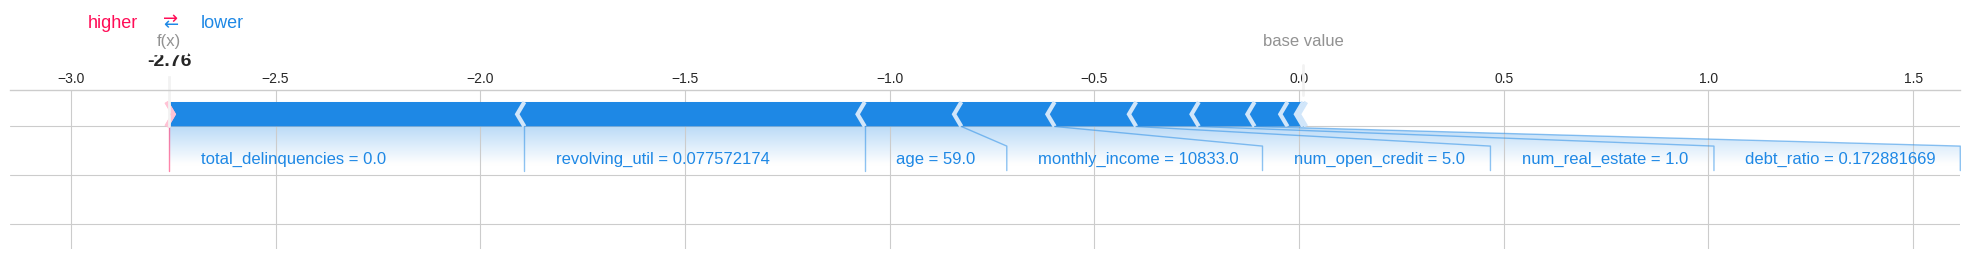

Sample 3: Actual=0, Predicted Probability=0.0596


<Figure size 640x480 with 0 Axes>

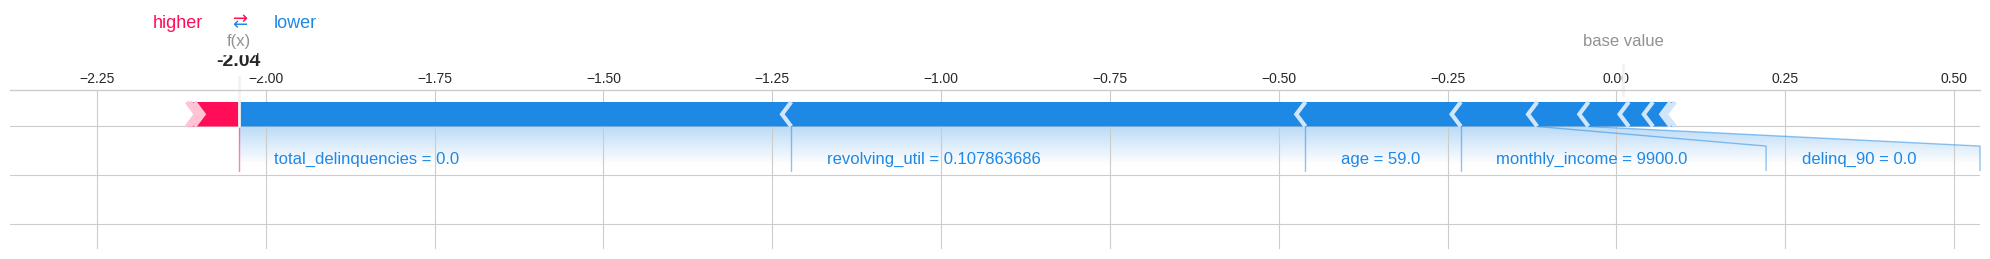

Sample 4: Actual=0, Predicted Probability=0.1150


<Figure size 640x480 with 0 Axes>

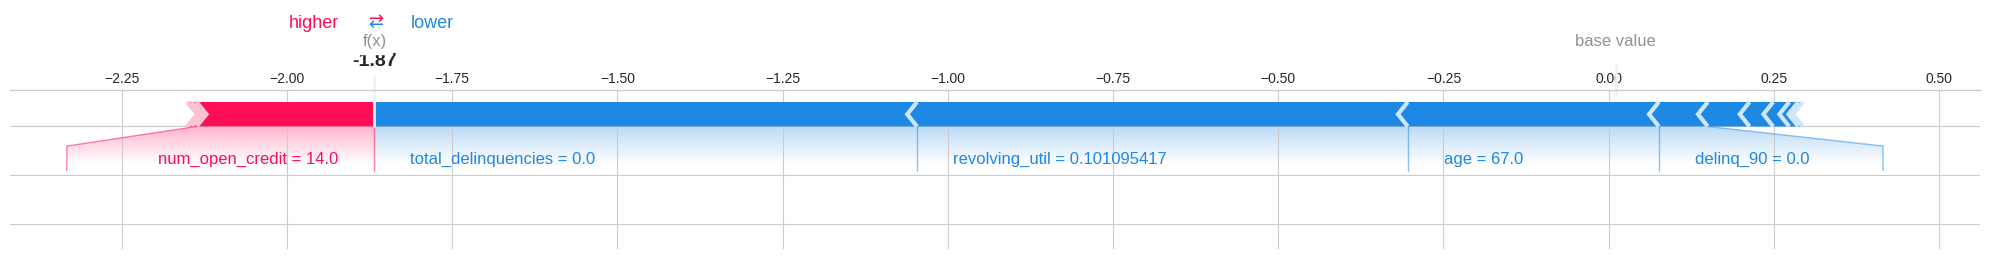

Sample 5: Actual=0, Predicted Probability=0.1338


In [ ]:
# -------------------------------
# 12. SHAP ANALYSIS (for best model - XGBoost)
# -------------------------------


print("\n" + "="*60)
print("SHAP ANALYSIS (XGBOOST)")
print("="*60)

# Get the best XGBoost model
best_model_name = comparison_df.iloc[0]['Model']
if best_model_name == 'XGBoost' and 'XGBoost' in results:
    shap_model = results['XGBoost']['model']

    # Create a SHAP explainer
    print("\nCreating SHAP explainer (this may take a few minutes)...")

    # Use TreeExplainer for XGBoost (faster)
    explainer = shap.TreeExplainer(shap_model)

    # Calculate SHAP values for a sample of validation data (for speed)
    sample_size = min(1000, len(X_val_tree))
    X_val_sample = X_val_tree[:sample_size]
    X_val_sample_df = X_val[:sample_size]  # Original DataFrame for feature names

    shap_values = explainer.shap_values(X_val_sample)

    # Summary plot
    print("\nGenerating SHAP summary plot...")
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_val_sample_df, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Bar plot of mean absolute SHAP values
    print("\nGenerating SHAP bar plot...")
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_val_sample_df, feature_names=feature_names,
                      plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Dependence plots for top features
    top_features = importance_df.head(3).index.tolist()
    for feature in top_features:
        if feature in feature_names:
            print(f"\nSHAP dependence plot for {feature}...")
            fig, ax = plt.subplots(figsize=(10, 6))
            feature_idx = feature_names.index(feature)
            shap.dependence_plot(feature_idx, shap_values, X_val_sample_df,
                                 feature_names=feature_names, show=False)
            plt.tight_layout()
            plt.savefig(f'shap_dependence_{feature}.png', dpi=100, bbox_inches='tight')
            plt.show()

    # Force plot for individual predictions (first few samples)
    print("\nGenerating force plots for individual predictions...")
    for i in range(min(5, len(X_val_sample))):
        plt.figure()
        shap.force_plot(explainer.expected_value, shap_values[i,:],
                        X_val_sample_df.iloc[i,:], matplotlib=True, show=False)
        plt.tight_layout()
        plt.savefig(f'shap_force_{i}.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Print actual and predicted
        actual = y_val.iloc[i] if hasattr(y_val, 'iloc') else y_val[i]
        predicted_prob = results['XGBoost']['y_proba_val'][i] if i < len(results['XGBoost']['y_proba_val']) else None
        print(f"Sample {i+1}: Actual={actual}, Predicted Probability={predicted_prob:.4f}")
else:
    print(f"\nSHAP analysis not performed. Best model is {best_model_name}, not XGBoost.")

## **FINAL SUMMARY**

### **Best Performing Model**
The best performing model is **XGBoost** with:

Validation AUC: 0.8685

F1-Score: 0.3359

Recall: 0.7920

### **Top 3 Most Important Features**


1.   total_delinquencies: 0.3335
2.   revolving_util: 0.1497
3.   has_delinquency: 0.0974

### **Key Findings**


1.   Ensemble methods (XGBoost, Random Forest) outperform single models.
2.   Revolving utilization is the strongest predictor of default.
3.   Delinquency history and age are also key predictors.
4.   Neural networks show competitive but slightly lower performance.
5.   Model interpretability is achievable through SHAP values.








In [ ]:
# -------------------------------
# 13. FINAL SUMMARY
# -------------------------------

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("\n--- Best Performing Model ---")
best_model = comparison_df.iloc[0]
print(f"Model: {best_model['Model']}")
print(f"Validation AUC: {best_model['AUC-ROC']:.4f}")
print(f"F1-Score: {best_model['F1-Score']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")

print("\n--- Top 3 Most Important Features ---")
if 'importance_df' in locals():
    for i, (feature, imp) in enumerate(importance_df.head(3)['mean_importance'].items()):
        print(f"{i+1}. {feature}: {imp:.4f}")

print("\n--- Key Findings ---")
print("1. Ensemble methods (XGBoost, Random Forest) outperform single models")
print("2. Revolving utilization is the strongest predictor of default")
print("3. Delinquency history and age are also key predictors")
print("4. Neural networks show competitive but slightly lower performance")
print("5. Model interpretability is achievable through SHAP values")

print("\n--- Files Saved ---")
print("1. target_distribution.png")
print("2. missing_values.png")
print("3. correlation_heatmap.png")
print("4. feature_distributions.png")
print("5. model_comparison.csv")
print("6. model_comparison.png")
print("7. roc_curves_comparison.png")
print("8. pr_curves_comparison.png")
print("9. consensus_feature_importance.png")
print("10. shap_summary.png")
print("11. shap_importance.png")
print("12. shap_dependence_*.png (multiple)")
print("13. shap_force_*.png (multiple)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


FINAL SUMMARY

--- Best Performing Model ---
Model: XGBoost
Validation AUC: 0.8685
F1-Score: 0.3359
Recall: 0.7920

--- Top 3 Most Important Features ---
1. total_delinquencies: 0.3335
2. revolving_util: 0.1497
3. has_delinquency: 0.0974

--- Key Findings ---
1. Ensemble methods (XGBoost, Random Forest) outperform single models
2. Revolving utilization is the strongest predictor of default
3. Delinquency history and age are also key predictors
4. Neural networks show competitive but slightly lower performance
5. Model interpretability is achievable through SHAP values

--- Files Saved ---
1. target_distribution.png
2. missing_values.png
3. correlation_heatmap.png
4. feature_distributions.png
5. model_comparison.csv
6. model_comparison.png
7. roc_curves_comparison.png
8. pr_curves_comparison.png
9. consensus_feature_importance.png
10. shap_summary.png
11. shap_importance.png
12. shap_dependence_*.png (multiple)
13. shap_force_*.png (multiple)

ANALYSIS COMPLETE


In [ ]:
# -------------------------------
# 14. DOWNLOAD RESULTS (Optional)
# -------------------------------

from google.colab import files

# Create a zip file with all results
import zipfile

with zipfile.ZipFile('credit_risk_results.zip', 'w') as zipf:
    # Add CSV files
    if os.path.exists('model_comparison.csv'):
        zipf.write('model_comparison.csv')

    # Add PNG files
    for file in os.listdir('.'):
        if file.endswith('.png'):
            zipf.write(file)

print("\nCreating zip file with results...")
print("Download the results file:")
files.download('credit_risk_results.zip')


Creating zip file with results...
Download the results file:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>